In [5]:
import numpy as np
import pyvista as pv
pv.start_xvfb()
pv.set_jupyter_backend('static')
from dataloaders import GetSingleStepDataLoaders
import sys
sys.path.append("/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/model")
from utils import *
data  = np.load('/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/data/test_comb_FOR_large_512.npz')
states = data['coords_t']
states_tp1 = data['coords_tp1']
steps = data['steps']
positions = data['positions']
rotations = data['rotations']
# actions = np.hstack((steps, positions, rotations))
actions = steps

point_size = states.shape[1]
latent_size = 512
batch_size = 32
output_folder = "./output_cogging/"
save_results = True
use_GPU = True
epochs = 201
max_rollout_horizon = 10


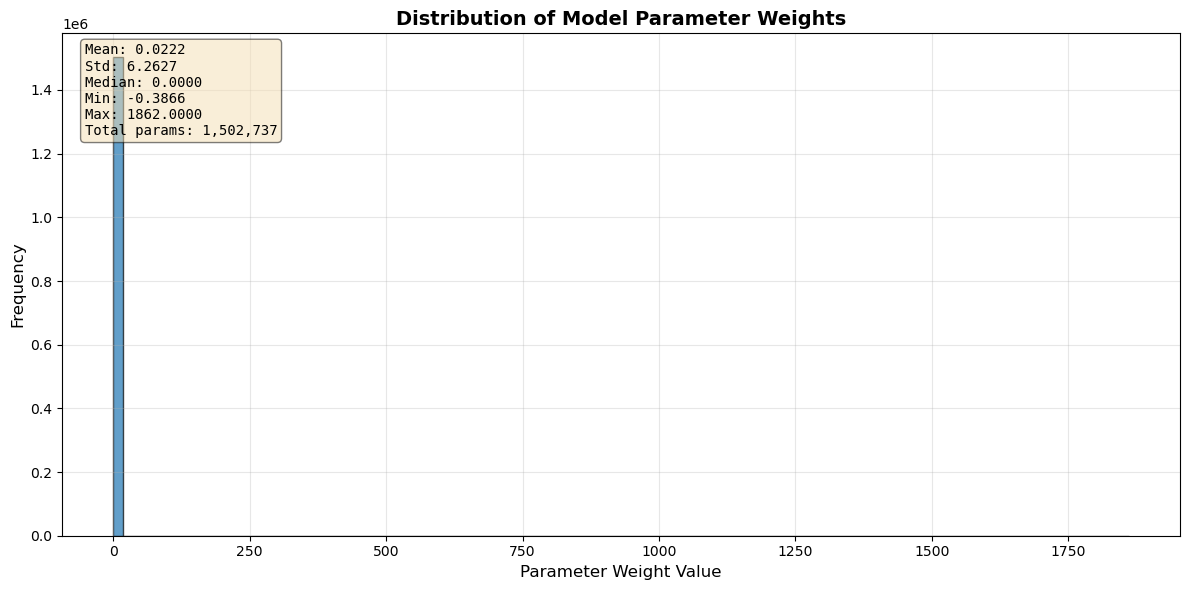

Histogram saved! Total parameters: 1,502,737
Weight statistics:
  Mean: 0.022223
  Std: 6.262692
  Min: -0.386598
  Max: 1862.000000


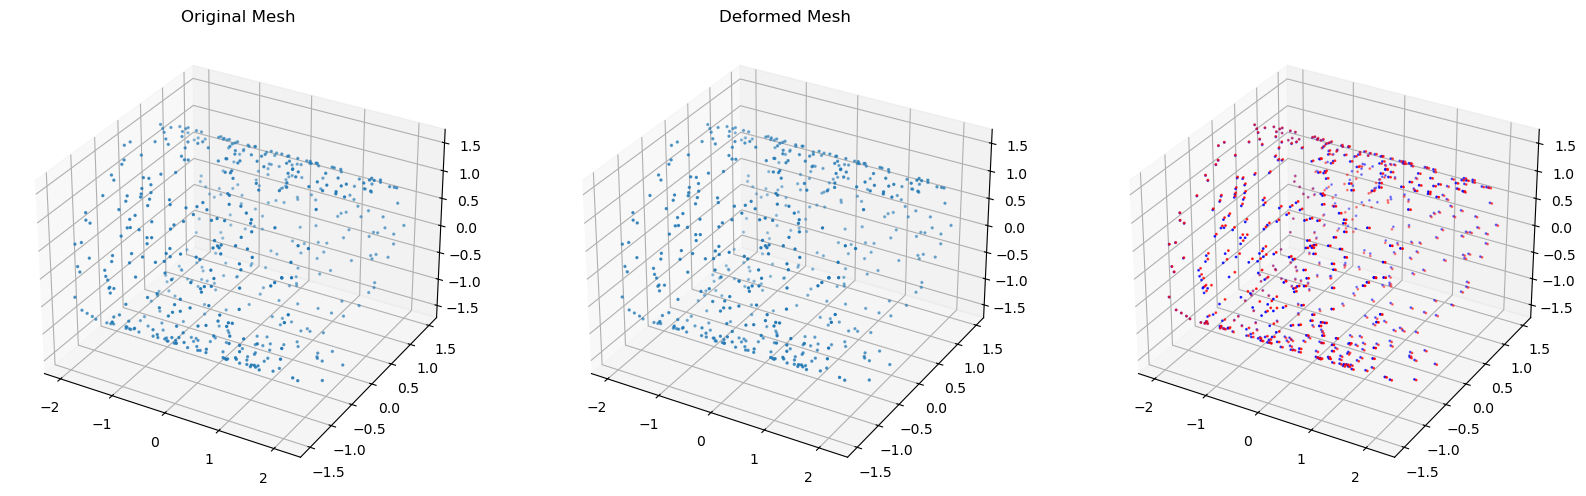

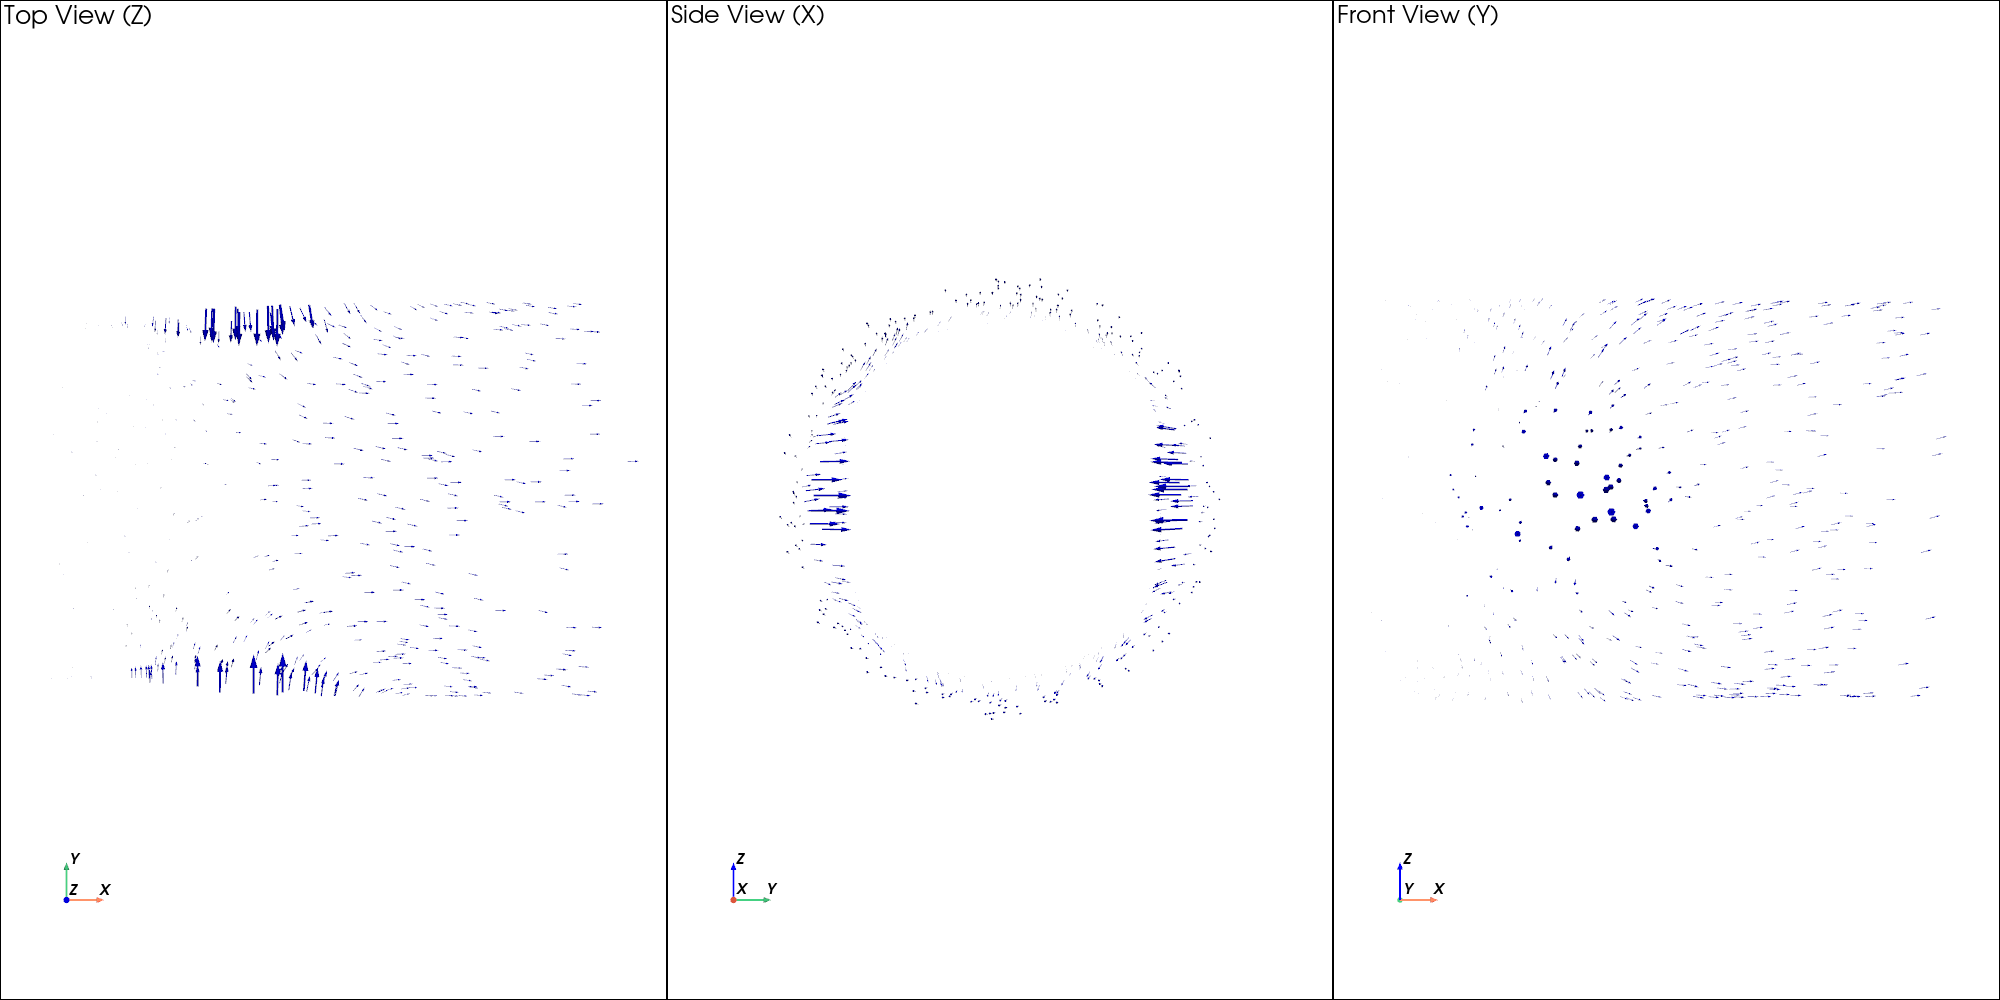

In [6]:
import torch
import model
idx = 65

model_path = "/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/model/output_cogging/best_model.pth"
state_dict = torch.load(model_path)['model_state_dict']
# model_path = "/local/scratch/groves/jax-forgeRL/transition_resmodel_comb_FOR_large_512.pth"

# model_path = "/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/model/transition_model_comb_FOR_large.pth"
# model_path = "/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/model/transition_resmodel_comb_FOR_large2.pth"
# state_dict = torch.load(model_path, weights_only=True)
plot_network_weights(state_dict)

# net = model.PCTransitionModel(point_size, latent_size)
net = model.ImprovedPCTransitionModel(
    point_size=point_size,
    latent_size=latent_size,     # Can try 256, 384, 512
    dropout=0.3    # Can tune 0.2-0.4       
)
net.load_state_dict(state_dict)
net.eval()
x_t = torch.tensor(states[idx], dtype=torch.float32).T.unsqueeze(0) # x.shape = 1,3,n_points
x_tp1 = torch.tensor(states_tp1[idx], dtype=torch.float32).T.unsqueeze(0) # x.shape = 1,3,n_points

a = torch.tensor(actions[idx], dtype=torch.float32).unsqueeze(0) #a.shape = 1,8
x_t_np = x_t.T.squeeze().numpy()
x_tp1_np = x_tp1.T.squeeze().numpy()


# visualize_point_cloud(c_t[25],a=-p[25], point_size=5)
compare_scatters(pc1=x_t_np, pc2=x_tp1_np, label_1="Original Mesh", label_2="Deformed Mesh")
visualize_vector_diff(x_t_np,x_tp1_np)


# pl = pv.Plotter()
# p = pv.PolyData(x_t_np)
# pl.add_mesh(p)
# pl.show()

In [7]:
# a = torch.tensor([0.5])

def forward(x,a):
    with torch.no_grad():
        return(net(x_t=x,a_t=a))

t = 1
for _ in range(t):

    delta = forward(x_t,a) / 25
    x_t = x_t.squeeze(0).T + delta.squeeze(0)
    x_t = x_t.T.unsqueeze(0)

x_hat = x_t.T.squeeze().numpy()


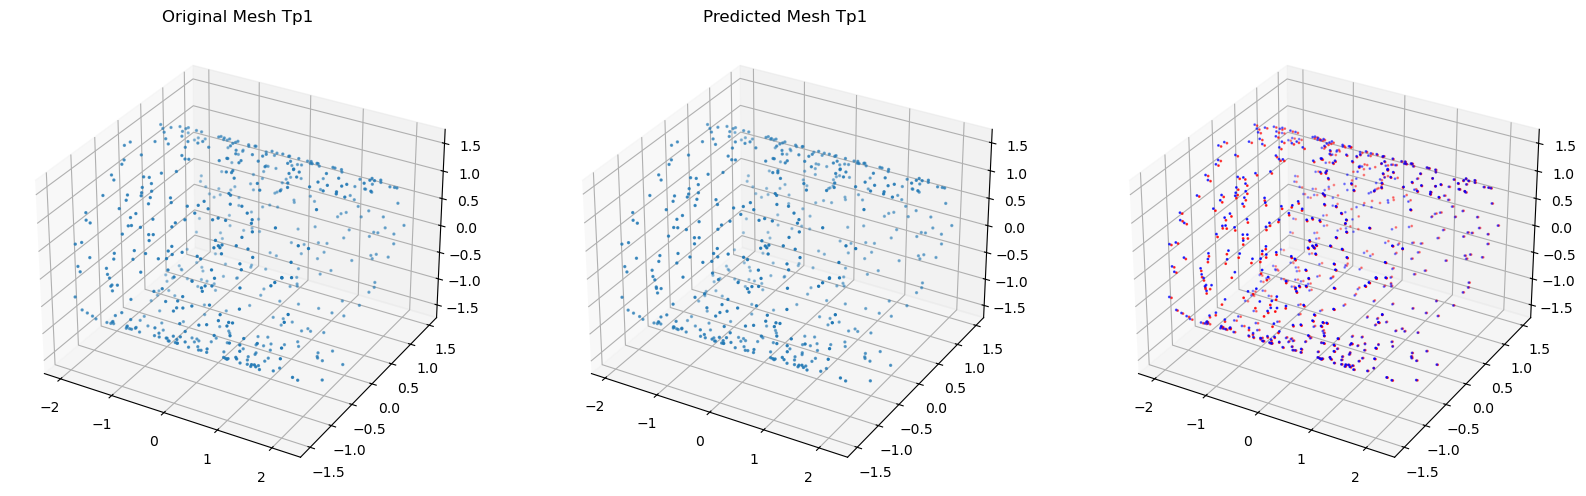

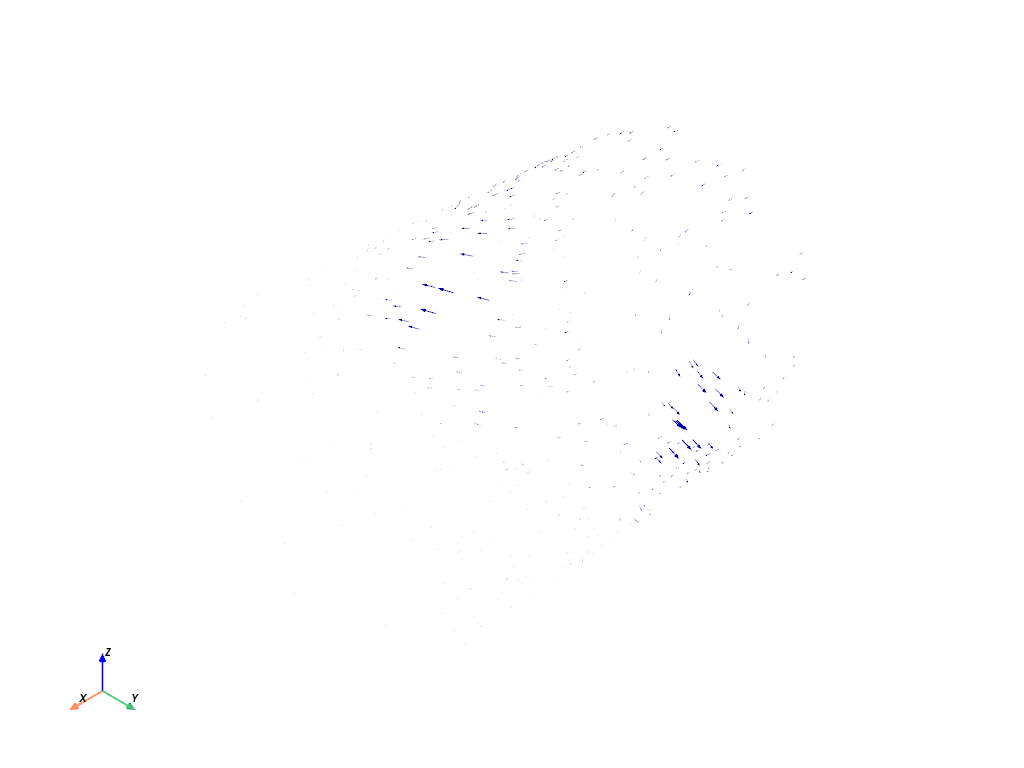

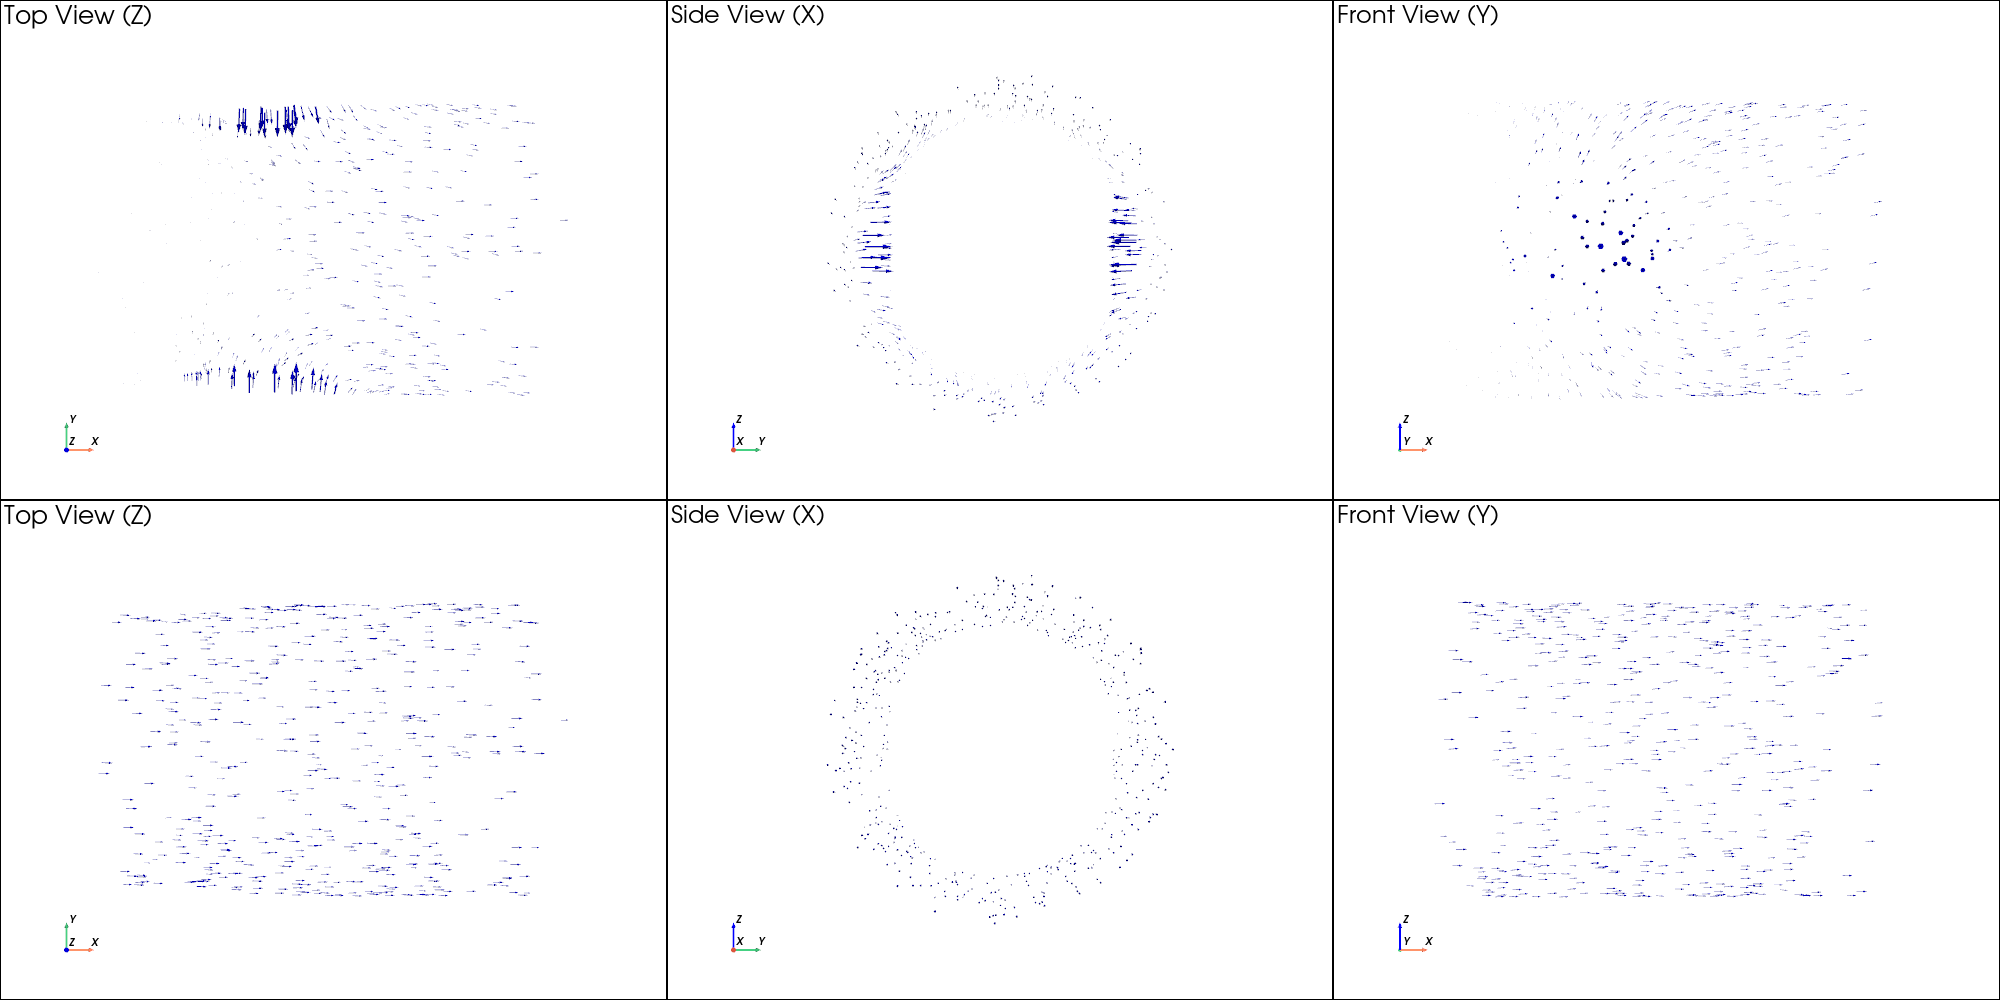

In [8]:
compare_scatters(pc1=x_tp1_np, pc2=x_hat, label_1="Original Mesh Tp1", label_2="Predicted Mesh Tp1")
visualize_point_diff(x_tp1_np, x_hat, point_size=5)
compare_vector_fields(x_t_np, x_tp1_np, x_hat)